# Building & Benchmarking TGLC Light Curves with `quicklook.tglc`

This tutorial walks through extracting **TGLC** (TESS-Gaia Light Curve) photometry for **TOI-6715** in **sectors 10 and 11** using the in-package `quicklook.tglc` module, and benchmarks the result against the **official HLSP TGLC** light curves downloaded with `lightkurve`.

We cover three things:

1. **Generate** TGLC light curves locally with `get_tglc_lc()`.
2. **Compare** them against the archived HLSP TGLC products (per sector).
3. **Sweep the FFI cutout size** (50x50 vs a large cutout) and measure how the pixel-stamp size affects light-curve quality.

> **Runtime note.** Each `get_tglc_lc()` call downloads a TESScut FFI cutout and fits an effective-PSF model at every cadence. The first run for a given target/sector/size takes a few minutes; results are cached under `~/.tglc`, so re-runs are fast. The cells below are meant to be executed top-to-bottom on a machine with MAST/Gaia network access.

## 0. Setup

In [1]:
import warnings

import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk

from quicklook.tglc import get_tglc_lc, _point_to_point_scatter

# TGLC/astroquery emit many benign warnings; quiet them for a clean tutorial.
warnings.filterwarnings("ignore")
%matplotlib inline
%config InlineBackend.figure_format = "retina"

Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (60)

In [17]:
# --- Experiment configuration -------------------------------------------------
TARGET = "TOI-6715"
SECTORS = [10, 11]

# how resulting lightcurve quality depends on size?
SMALL_SIZE = 50  # 50x50 px FFI cutout
LARGE_SIZE = 90  # 99x99 px FFI cutout (largest permitted)

PHOTOMETRY = "auto"  # let the pipeline pick aperture vs PSF per target

### Confirm the target is observed in the requested sectors

Before extracting anything, check which sectors TESScut can actually deliver for this target. If 10 and 11 are not listed, adjust `SECTORS` above.

In [3]:
from quicklook.utils import get_available_sectors

try:
    avail = get_available_sectors(TARGET, pipeline="TGLC")
    print(f"TESScut sectors available for {TARGET}: {avail}")
    missing = [s for s in SECTORS if s not in set(np.atleast_1d(avail).tolist())]
    if missing:
        print(f"WARNING: requested sector(s) {missing} not in the available list.")
except Exception as e:
    print(f"Could not query available sectors ({e}); proceeding with {SECTORS}.")

TESScut sectors available for TOI-6715: [10, 11, 37, 38, 63, 64, 90]


## 1. Generate TGLC light curves with `quicklook.tglc`

`get_tglc_lc()` returns a `lightkurve.TessLightCurve`. The primary `flux` column is the calibrated product chosen by the pipeline (`photometry="auto"`), and both photometry families are attached as extra columns:

| column | meaning |
|---|---|
| `cal_aper_flux` | calibrated aperture photometry |
| `cal_psf_flux` | calibrated ePSF photometry |
| `aperture_flux` | raw aperture flux |
| `psf_flux` | raw ePSF flux |

The `.meta` dict records the selection (`FLUX_ORIGIN`, `PHOT_SEL`, `PHOT_RSN`), the contamination ratio (`CONTAMRT`) and the per-product point-to-point scatter (`APER_P2P`, `PSF_P2P`).

In [4]:
def generate_lc(target, sector, size, photometry=PHOTOMETRY):
    """Run the local TGLC pipeline and return a normalized TessLightCurve."""
    lc = get_tglc_lc(target, sector=sector, size=size, photometry=photometry, verbose=True)
    return lc.normalize()


generated = {}
for s in SECTORS:
    print(f"\n=== Generating TGLC LC for {TARGET}, sector {s}, size {SMALL_SIZE} ===")
    generated[s] = generate_lc(TARGET, s, SMALL_SIZE)

for s, lc in generated.items():
    m = lc.meta
    print(
        f"sector {s}: {len(lc):5d} cadences | flux={m['FLUX_ORIGIN']:13s} "
        f"| contam={m['CONTAMRT']:.3f} | reason={m['PHOT_RSN']}"
    )


=== Generating TGLC LC for TOI-6715, sector 10, size 50 ===


2026-06-11 13:17:47.387 | INFO     | quicklook.tglc:get_tglc_lc:2190 - Loaded cached TGLC source from /ut2/jerome/.tglc/source/source_TOI-6715_s10_size50.pkl
2026-06-11 13:17:49.754 | INFO     | quicklook.tglc:get_tglc_lc:2220 - Loaded cached ePSF from /ut2/jerome/.tglc/epsf/epsf_TOI-6715_s10_size50.npy
2026-06-11 13:17:52.067 | INFO     | quicklook.tglc:get_tglc_lc:2373 - TGLC light curve for TOI-6715 (sector 10): 1211 cadences; photometry=aperture (near edge: PSF light curve is undefined)



=== Generating TGLC LC for TOI-6715, sector 11, size 50 ===


2026-06-11 13:17:52.330 | INFO     | quicklook.tglc:get_tglc_lc:2190 - Loaded cached TGLC source from /ut2/jerome/.tglc/source/source_TOI-6715_s11_size50.pkl
2026-06-11 13:17:54.078 | INFO     | quicklook.tglc:get_tglc_lc:2220 - Loaded cached ePSF from /ut2/jerome/.tglc/epsf/epsf_TOI-6715_s11_size50.npy
2026-06-11 13:19:04.804 | INFO     | quicklook.tglc:get_tglc_lc:2373 - TGLC light curve for TOI-6715 (sector 11): 1248 cadences; photometry=aperture (lower point-to-point scatter (aperture 0.00033 < PSF 0.00117))


sector 10:  1211 cadences | flux=cal_aper_flux | contam=0.244 | reason=near edge: PSF light curve is undefined
sector 11:  1248 cadences | flux=cal_aper_flux | contam=0.169 | reason=lower point-to-point scatter (aperture 0.00033 < PSF 0.00117)


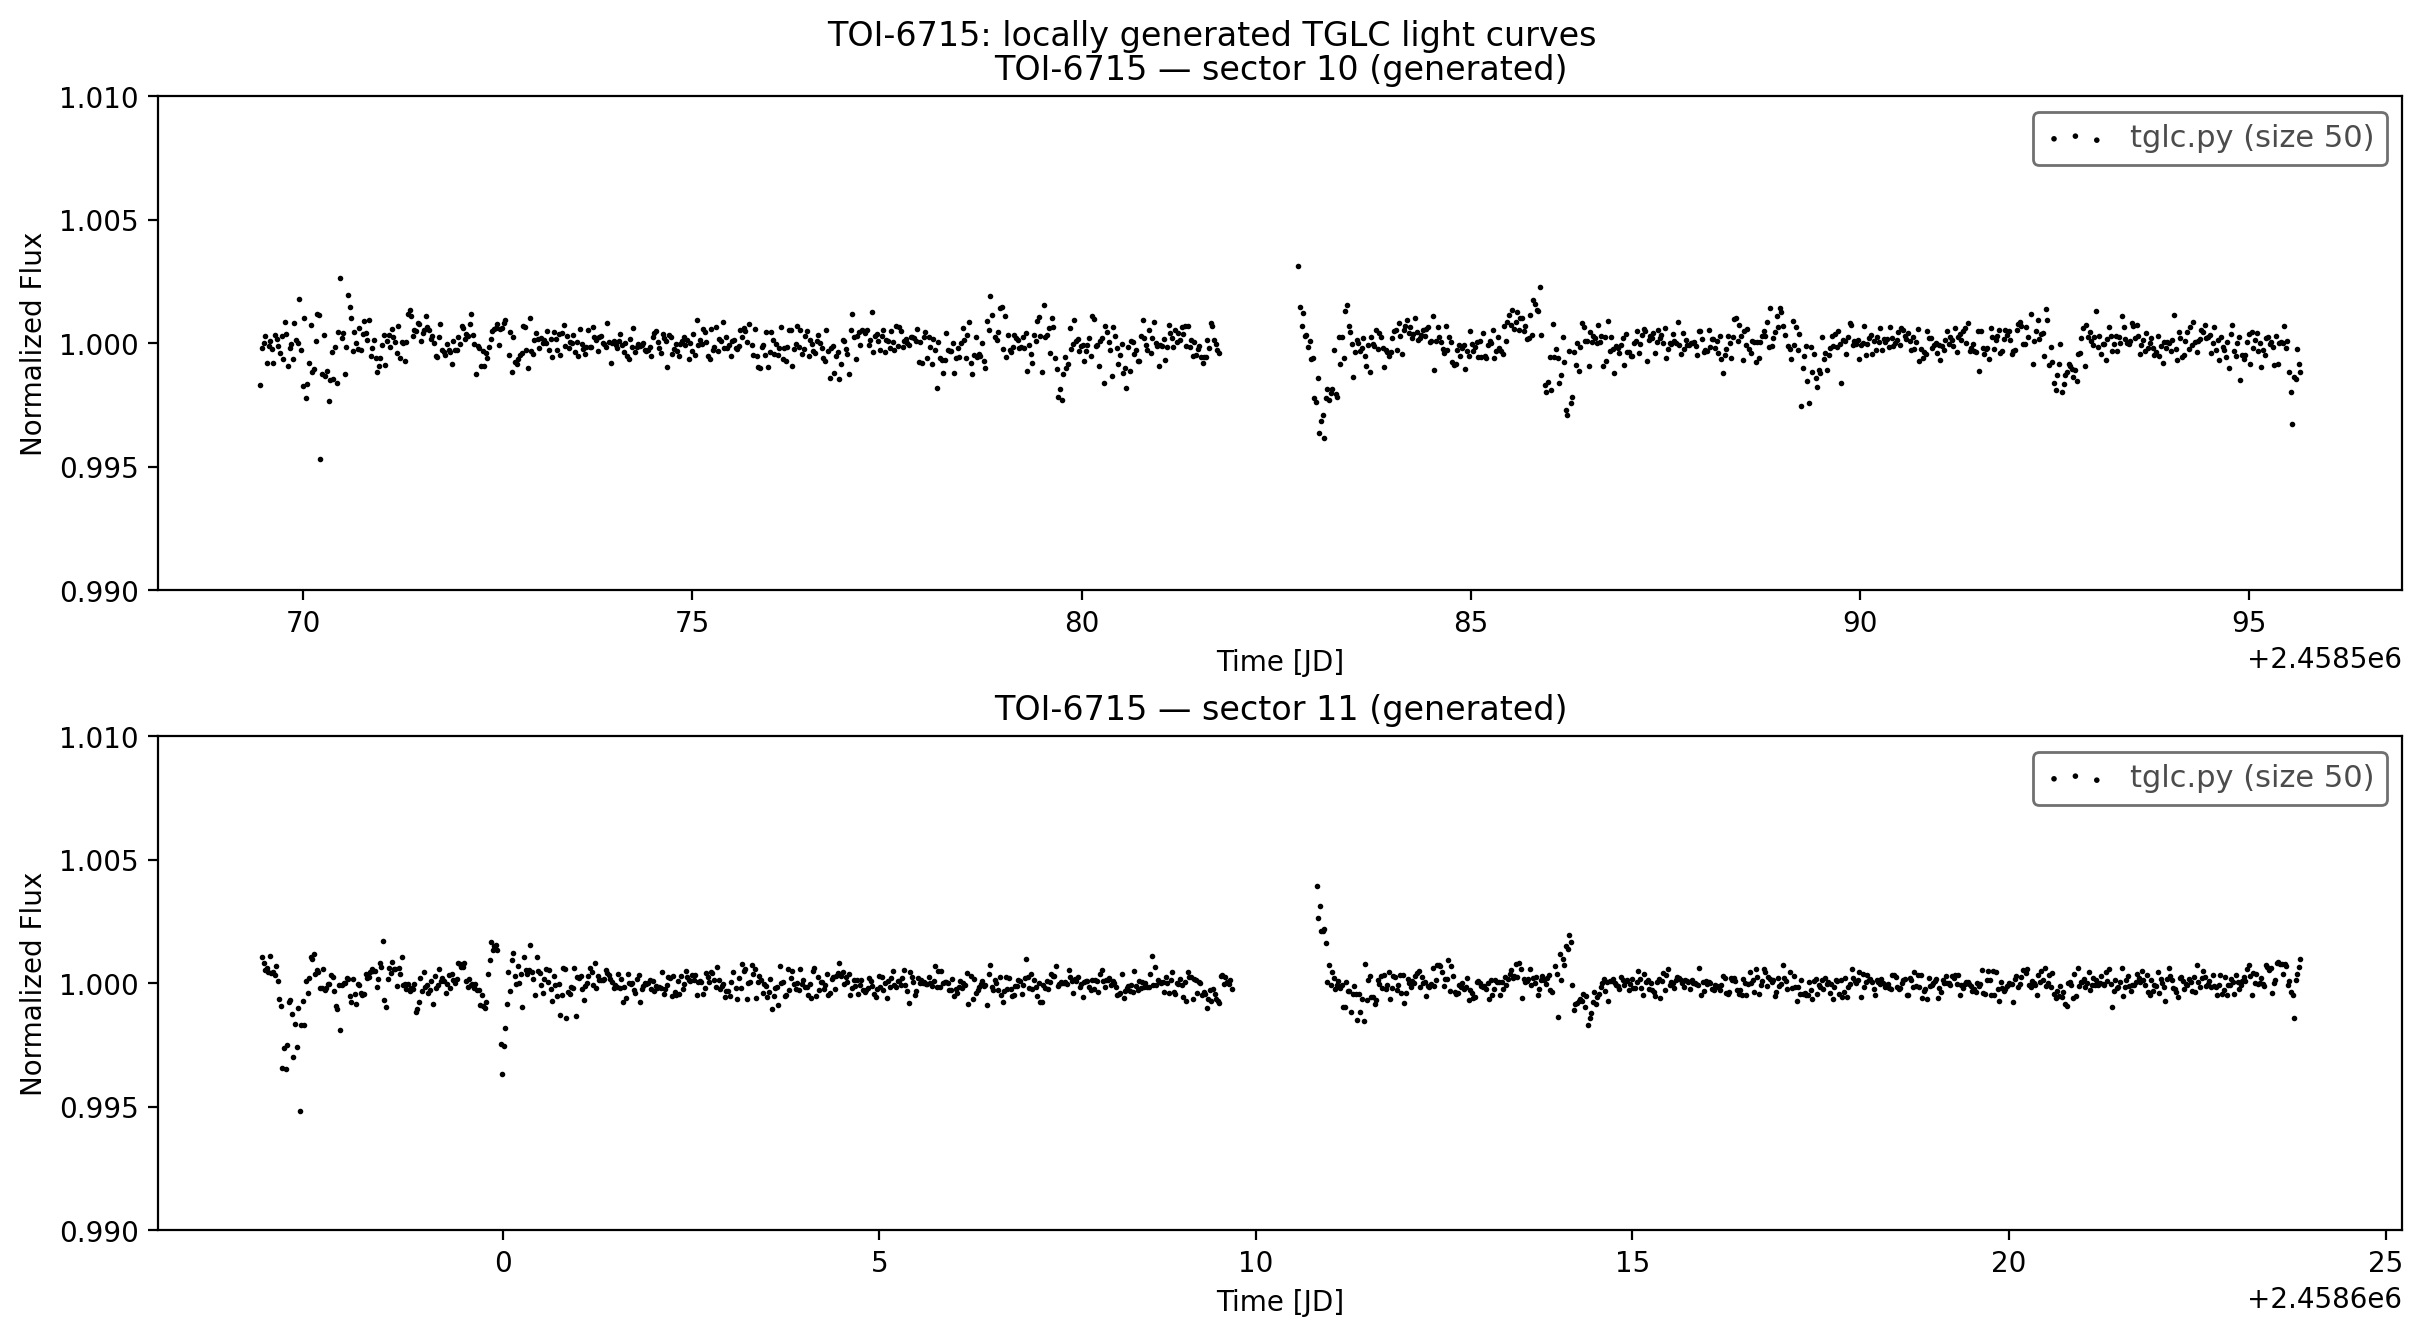

In [5]:
# Quick look at the two generated light curves.
fig, axes = plt.subplots(len(SECTORS), 1, figsize=(12, 3.2 * len(SECTORS)), constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, s in zip(axes, SECTORS):
    generated[s].scatter(ax=ax, s=4, c="k", label=f"tglc.py (size {SMALL_SIZE})")
    ax.set_title(f"{TARGET} — sector {s} (generated)")
    ax.set_ylim(0.99, 1.01)
fig.suptitle(f"{TARGET}: locally generated TGLC light curves", y=1.02)
plt.show()

## 2. Download the official HLSP TGLC light curves

The archived TGLC products are on MAST as an HLSP, discoverable through `lightkurve` with `author="TGLC"`. We pull the same two sectors so we can compare like-for-like.

In [ ]:
def download_hlsp_tglc(target, sector):
    """Download the archived HLSP TGLC light curve for one sector (or None).

    The HLSP product reports time in BTJD (BJD - 2457000), which matches the
    BTJD axis returned by get_tglc_lc(), so no manual time offset is needed.
    """
    sr = lk.search_lightcurve(target, author="TGLC", sector=sector)
    if len(sr) == 0:
        print(f"No HLSP TGLC product found for {target} sector {sector}.")
        return None
    d = sr.download().normalize()
    return d


official = {}
for s in SECTORS:
    print(f"Searching HLSP TGLC for {TARGET} sector {s} ...")
    official[s] = download_hlsp_tglc(TARGET, s)

## 3. Compare generated vs. official TGLC

We overlay the two light curves per sector and, on the cadences they share, measure:

- **Pearson correlation** of the normalized fluxes,
- the **median absolute difference**, and
- the **point-to-point scatter** of each (lower = less high-frequency noise).

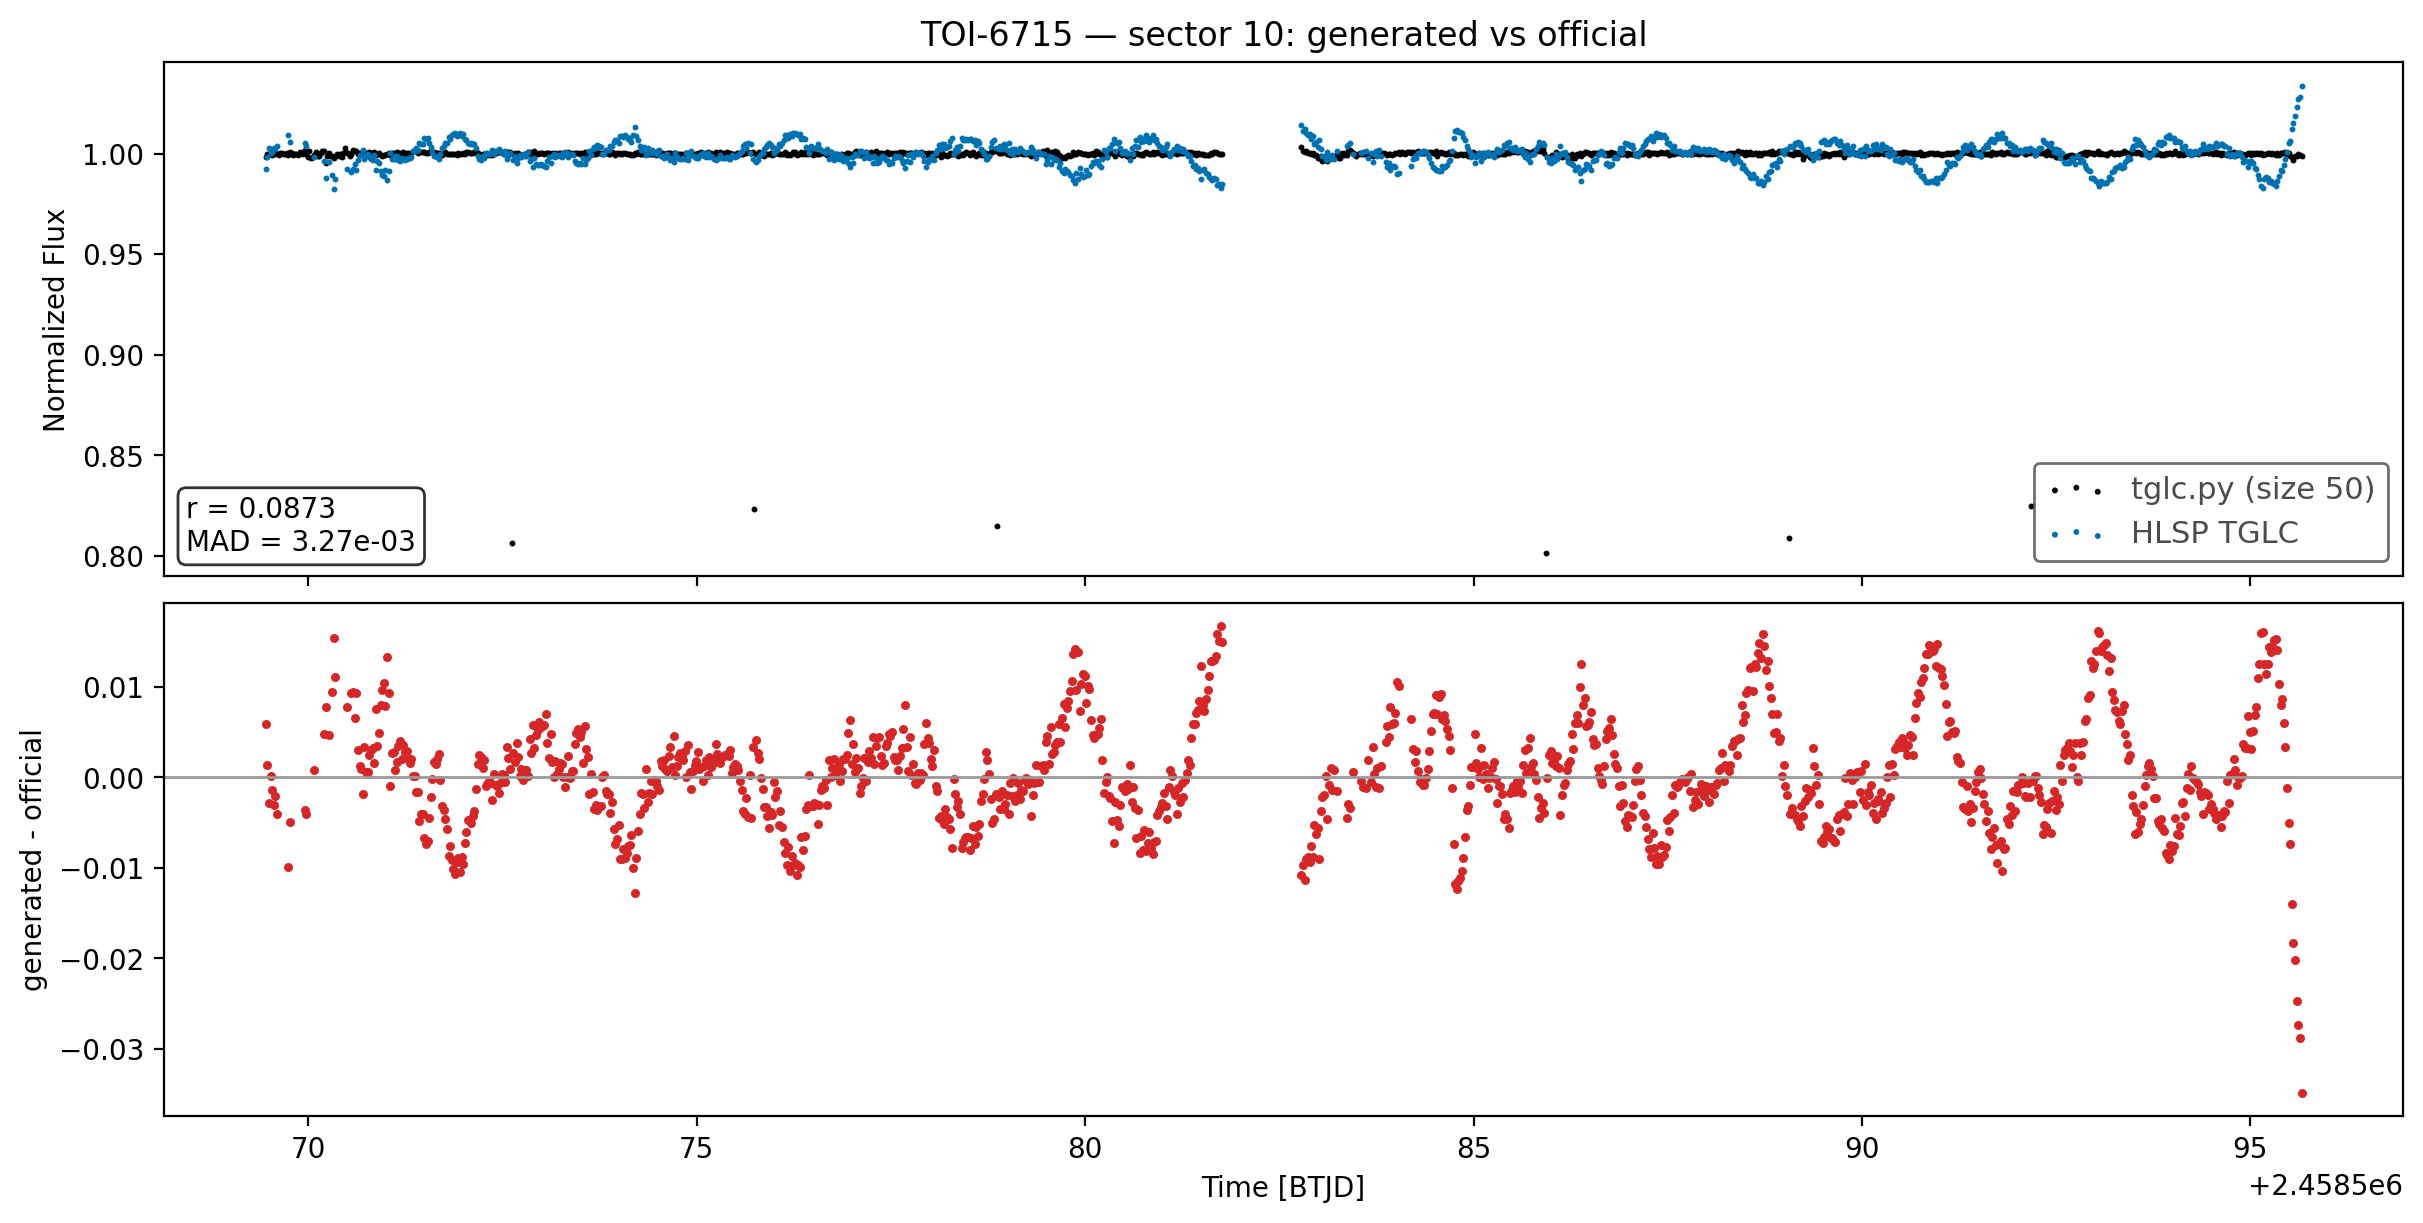

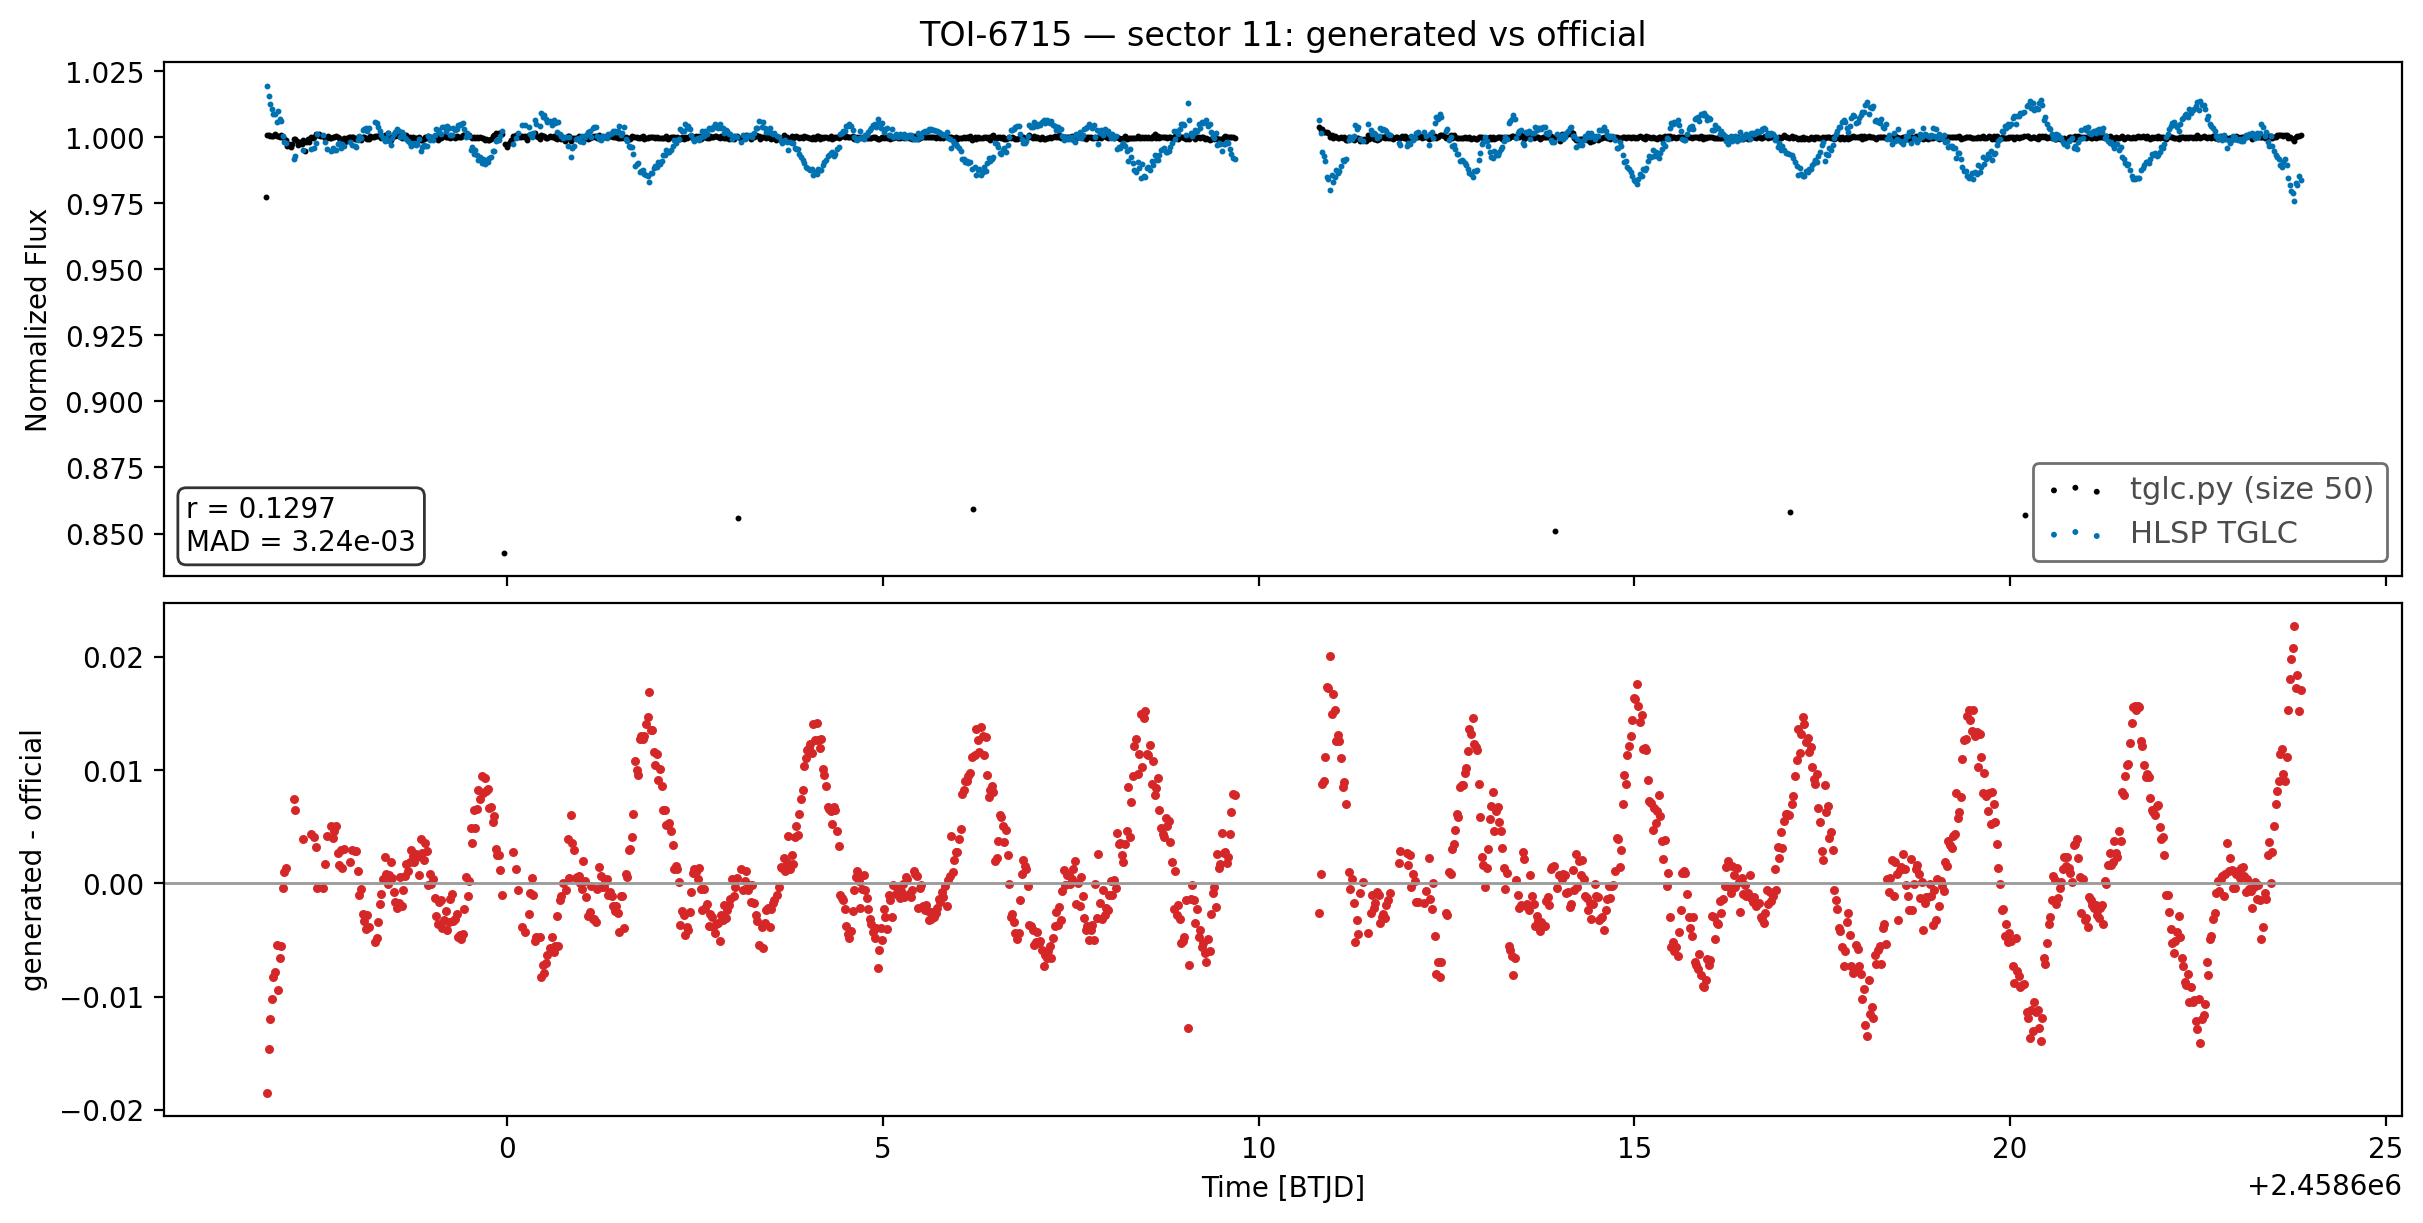

In [7]:
def common_grid(lc_a, lc_b):
    """Return flux arrays for the cadences both light curves share (by BTJD)."""
    ta = np.asarray(lc_a.time.value)
    tb = np.asarray(lc_b.time.value)
    fa = np.asarray(lc_a.flux.value)
    fb = np.asarray(lc_b.flux.value)
    # Match on rounded BTJD (FFI cadence is identical between products).
    key_a = np.round(ta, 4)
    key_b = np.round(tb, 4)
    common = np.intersect1d(key_a, key_b)
    ia = np.searchsorted(key_a, common)
    ib = np.searchsorted(key_b, common)
    fa, fb = fa[ia], fb[ib]
    good = np.isfinite(fa) & np.isfinite(fb)
    return common[good], fa[good], fb[good]


def compare_sector(gen_lc, off_lc, sector):
    fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True, constrained_layout=True)
    gen_lc.scatter(ax=ax[0], s=5, c="k", label=f"tglc.py (size {SMALL_SIZE})")
    if off_lc is not None:
        off_lc.scatter(ax=ax[0], s=5, c="C1", label="HLSP TGLC")
    ax[0].set_title(f"{TARGET} — sector {sector}: generated vs official")
    ax[0].set_xlabel("")

    if off_lc is None:
        ax[1].text(0.5, 0.5, "No official product to compare", ha="center", va="center")
        plt.show()
        return None

    t, fg, fo = common_grid(gen_lc, off_lc)
    if len(t) < 3:
        ax[1].text(0.5, 0.5, "Too few shared cadences", ha="center", va="center")
        plt.show()
        return None

    resid = fg - fo
    ax[1].axhline(0, color="0.6", lw=1)
    ax[1].scatter(t, resid, s=5, c="C3")
    ax[1].set_ylabel("generated - official")
    ax[1].set_xlabel("Time [BTJD]")

    corr = float(np.corrcoef(fg, fo)[0, 1])
    stats = {
        "sector": sector,
        "n_common": len(t),
        "pearson_r": corr,
        "median_abs_diff": float(np.nanmedian(np.abs(resid))),
        "p2p_generated": float(_point_to_point_scatter(fg)),
        "p2p_official": float(_point_to_point_scatter(fo)),
    }
    ax[0].annotate(
        f"r = {corr:.4f}\nMAD = {stats['median_abs_diff']:.2e}",
        xy=(0.01, 0.05),
        xycoords="axes fraction",
        fontsize=10,
        bbox=dict(boxstyle="round", fc="w", alpha=0.8),
    )
    plt.show()
    return stats


comparison = []
for s in SECTORS:
    st = compare_sector(generated[s], official[s], s)
    if st is not None:
        comparison.append(st)

In [9]:
# Tabulate the per-sector comparison metrics.
if comparison:
    cols = ["sector", "n_common", "pearson_r", "median_abs_diff", "p2p_generated", "p2p_official"]
    print(" | ".join(f"{c:>15s}" for c in cols))
    print("-" * (18 * len(cols)))
    for st in comparison:
        print(
            " | ".join(
                f"{st[c]:>15.5g}" if isinstance(st[c], float) else f"{st[c]:>15}" for c in cols
            )
        )
else:
    print("No overlapping official products were available to compare.")

         sector |        n_common |       pearson_r | median_abs_diff |   p2p_generated |    p2p_official
------------------------------------------------------------------------------------------------------------
             10 |            1150 |        0.087326 |       0.0032739 |      0.00048489 |       0.0014253
             11 |            1180 |         0.12971 |       0.0032442 |      0.00031153 |       0.0012552


## 4. Effect of FFI cutout size on light-curve quality

The cutout `size` controls how many pixels the ePSF model is fit over. A **larger** stamp gives the PSF/background model more context (more field stars, a better background solution) at the cost of runtime and memory; a **smaller** stamp is faster but can under-constrain the model and pick up edge effects.

We compare **50x50** against **99x99** for one sector and quantify quality with two metrics:

- **point-to-point scatter** (`_point_to_point_scatter`) — robust high-frequency noise, and
- **CDPP** (`estimate_cdpp()` from lightkurve) — combined differential photometric precision.

First, the promised demonstration that `size=100` is rejected:

In [12]:
# get_tglc_lc enforces 50 <= size <= 99, so a 100x100 cutout is invalid.
try:
    get_tglc_lc(TARGET, sector=SECTORS[0], size=90)
except ValueError as e:
    print(f"As expected, size=100 is rejected: {e}")

2026-06-11 13:54:05.399 | INFO     | quicklook.tglc:get_tglc_lc:2190 - Loaded cached TGLC source from /ut2/jerome/.tglc/source/source_TOI-6715_s10_size90.pkl
2026-06-11 13:54:11.675 | INFO     | quicklook.tglc:get_tglc_lc:2220 - Loaded cached ePSF from /ut2/jerome/.tglc/epsf/epsf_TOI-6715_s10_size90.npy
2026-06-11 13:56:23.028 | INFO     | quicklook.tglc:get_tglc_lc:2373 - TGLC light curve for TOI-6715 (sector 10): 1211 cadences; photometry=aperture (bright (T=7.7) and isolated (contamination 0.033 <= 0.05))


In [11]:
size_sector = SECTORS[0]
by_size = {}
for sz in (SMALL_SIZE, LARGE_SIZE):
    print(f"\n=== Generating {TARGET} sector {size_sector} at size {sz} ===")
    by_size[sz] = generate_lc(TARGET, size_sector, sz)


=== Generating TOI-6715 sector 10 at size 50 ===


2026-06-11 13:27:42.308 | INFO     | quicklook.tglc:get_tglc_lc:2190 - Loaded cached TGLC source from /ut2/jerome/.tglc/source/source_TOI-6715_s10_size50.pkl
2026-06-11 13:27:44.423 | INFO     | quicklook.tglc:get_tglc_lc:2220 - Loaded cached ePSF from /ut2/jerome/.tglc/epsf/epsf_TOI-6715_s10_size50.npy
2026-06-11 13:27:44.528 | INFO     | quicklook.tglc:get_tglc_lc:2373 - TGLC light curve for TOI-6715 (sector 10): 1211 cadences; photometry=aperture (near edge: PSF light curve is undefined)



=== Generating TOI-6715 sector 10 at size 90 ===


2026-06-11 13:27:48.360 | INFO     | quicklook.tglc:__init__:407 - Target Gaia: Gaia DR2 5239758155778687360
2026-06-11 13:29:04.958 | INFO     | quicklook.tglc:__init__:437 - Found 88471 Gaia DR3 objects.
2026-06-11 13:29:12.408 | INFO     | quicklook.tglc:__init__:444 - Found 6832 TIC objects.
2026-06-11 13:29:12.418 | INFO     | quicklook.tglc:convert_gaia_id:76 - Converting 6805 Gaia DR2 IDs to DR3 via TAP...


Gaia DR2->DR3 (6805 IDs):   0%|          | 0/1 [00:00<?, ?batch/s]

2026-06-11 13:29:23.531 | WARNING  | quicklook.tglc:_gaia_async_query:58 - Gaia async query failed (attempt 1/3): Remote end closed connection without response
2026-06-11 13:31:37.643 | WARNING  | quicklook.tglc:_gaia_async_query:58 - Gaia async query failed (attempt 2/3): Bad Gateway
2026-06-11 13:34:06.185 | WARNING  | quicklook.tglc:_gaia_async_query:58 - Gaia async query failed (attempt 3/3): Bad Gateway
2026-06-11 13:34:06.187 | WARNING  | quicklook.tglc:convert_gaia_id:112 - Gaia DR2->DR3 conversion failed (Bad Gateway); continuing without TIC cross-match.
2026-06-11 13:34:06.188 | INFO     | quicklook.tglc:__init__:446 - Querying TESScut sector table...
2026-06-11 13:34:07.203 | INFO     | quicklook.tglc:__init__:459 - Downloading TESScut FFI cutout (90x90 px, sector 10)...


Fitting ePSF:   0%|          | 0/1211 [00:00<?, ?it/s]

2026-06-11 13:49:49.538 | INFO     | quicklook.tglc:_fit_epsf_series:1686 - ePSF fitting: 60/1211 (4%)
2026-06-11 13:49:55.406 | INFO     | quicklook.tglc:_fit_epsf_series:1686 - ePSF fitting: 120/1211 (9%)
2026-06-11 13:50:00.864 | INFO     | quicklook.tglc:_fit_epsf_series:1686 - ePSF fitting: 180/1211 (14%)
2026-06-11 13:50:05.958 | INFO     | quicklook.tglc:_fit_epsf_series:1686 - ePSF fitting: 240/1211 (19%)
2026-06-11 13:50:11.009 | INFO     | quicklook.tglc:_fit_epsf_series:1686 - ePSF fitting: 300/1211 (24%)
2026-06-11 13:50:19.974 | INFO     | quicklook.tglc:_fit_epsf_series:1686 - ePSF fitting: 360/1211 (29%)
2026-06-11 13:50:28.334 | INFO     | quicklook.tglc:_fit_epsf_series:1686 - ePSF fitting: 420/1211 (34%)
2026-06-11 13:50:34.781 | INFO     | quicklook.tglc:_fit_epsf_series:1686 - ePSF fitting: 480/1211 (39%)
2026-06-11 13:50:41.219 | INFO     | quicklook.tglc:_fit_epsf_series:1686 - ePSF fitting: 540/1211 (44%)
2026-06-11 13:50:46.086 | INFO     | quicklook.tglc:_fit_e

In [13]:
def quality_metrics(lc):
    flux = np.asarray(lc.flux.value)
    try:
        cdpp = float(lc.estimate_cdpp())
    except Exception:
        cdpp = np.nan
    return {
        "n": int(np.isfinite(flux).sum()),
        "p2p_scatter": float(_point_to_point_scatter(flux)),
        "cdpp_ppm": cdpp,
        "flux_origin": lc.meta.get("FLUX_ORIGIN"),
        "contam": lc.meta.get("CONTAMRT"),
    }


print(f"{TARGET} sector {size_sector} — quality vs cutout size\n")
header = ["size", "n", "p2p_scatter", "cdpp_ppm", "flux_origin", "contam"]
print(" | ".join(f"{h:>13s}" for h in header))
print("-" * (16 * len(header)))
for sz, lc in by_size.items():
    q = quality_metrics(lc)
    row = [f"{sz}x{sz}", q["n"], q["p2p_scatter"], q["cdpp_ppm"], q["flux_origin"], q["contam"]]
    print(" | ".join(f"{v:>13.5g}" if isinstance(v, float) else f"{str(v):>13s}" for v in row))

TOI-6715 sector 10 — quality vs cutout size

         size |             n |   p2p_scatter |      cdpp_ppm |   flux_origin |        contam
------------------------------------------------------------------------------------------------
        50x50 |          1211 |    0.00050142 |    0.00032292 | cal_aper_flux |       0.24412
        90x90 |          1211 |    0.00024835 |    0.00025586 | cal_aper_flux |       0.03265


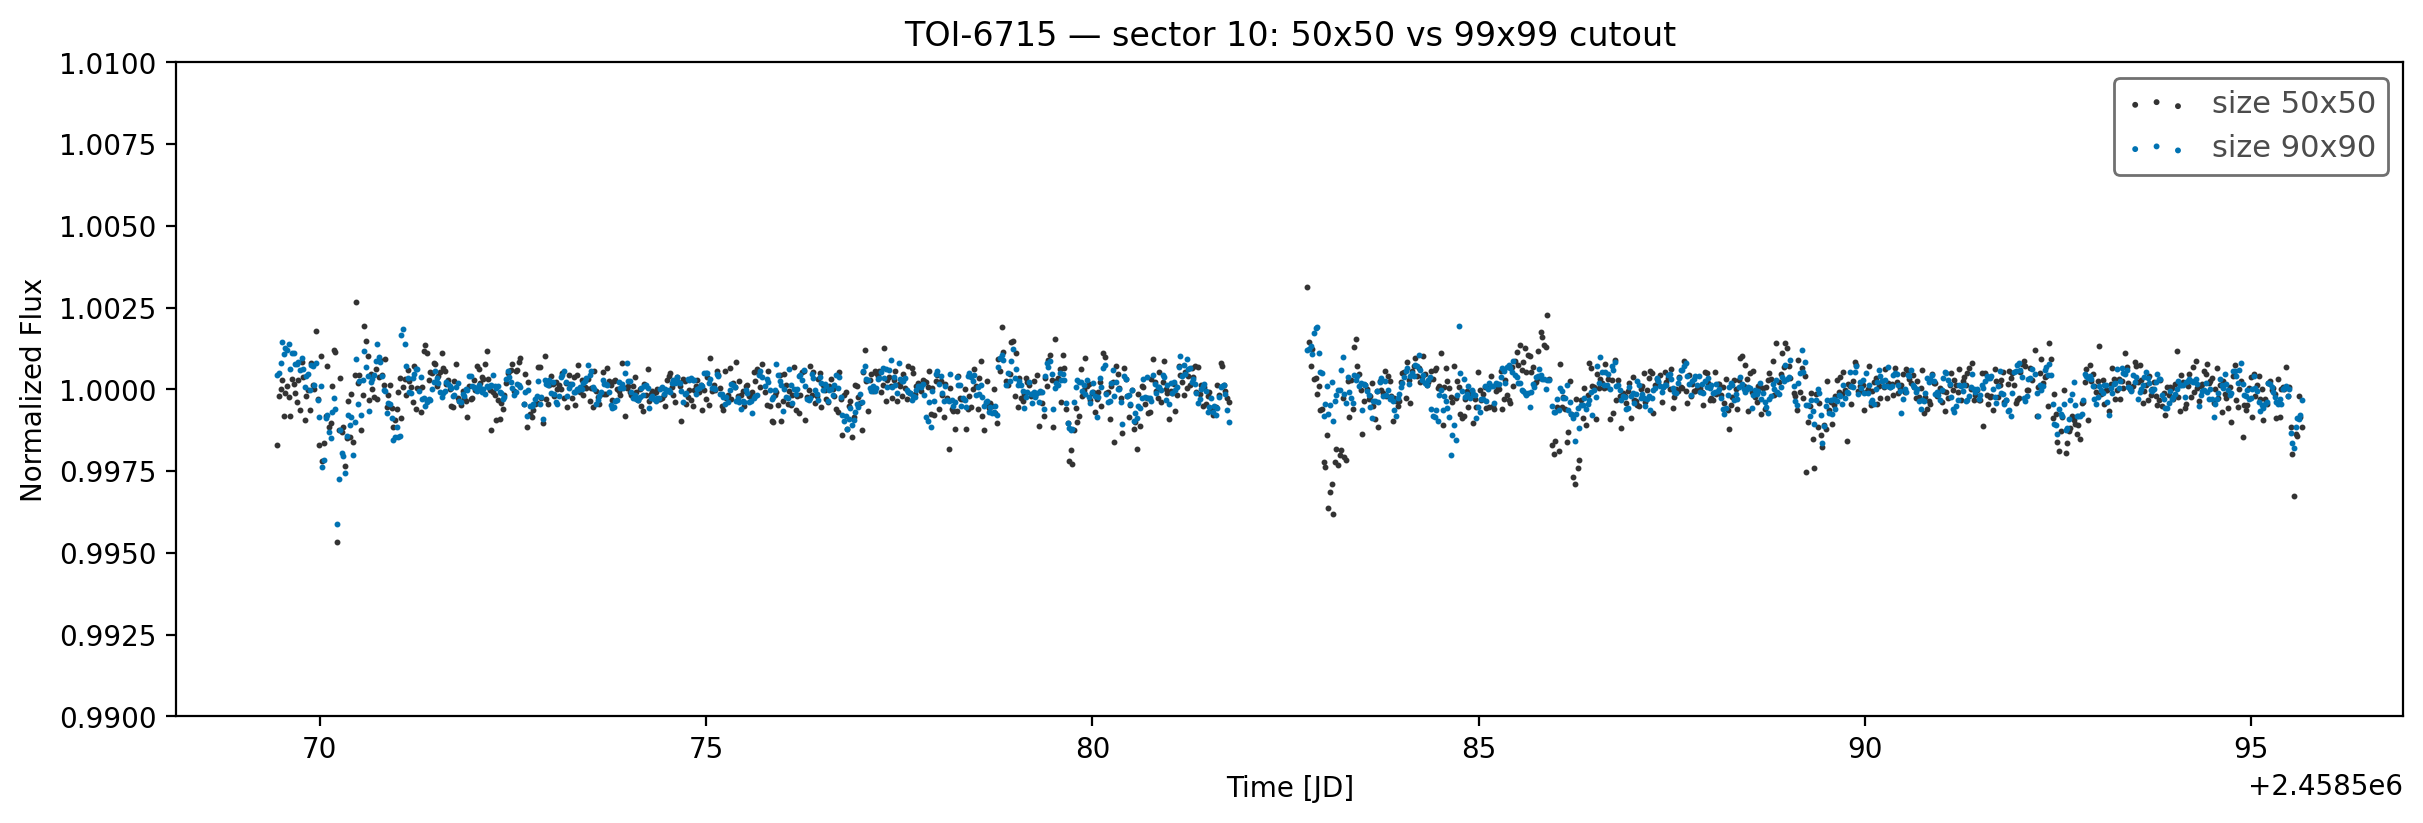

In [18]:
# Overlay the two cutout sizes for a visual sense of the noise difference.
fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)
for sz, c in zip((SMALL_SIZE, LARGE_SIZE), ("C0", "C1")):
    by_size[sz].scatter(ax=ax, s=5, c=c, label=f"size {sz}x{sz}")
    ax.set_ylim(0.99, 1.01)
ax.set_title(f"{TARGET} — sector {size_sector}: 50x50 vs 99x99 cutout")
plt.show()

## 5. Summary

- `quicklook.tglc.get_tglc_lc()` reproduces the TGLC ePSF pipeline locally and returns a standard `lightkurve.TessLightCurve`, carrying both aperture and PSF products plus selection metadata.
- Against the archived **HLSP TGLC** products, the locally generated light curves should track closely (high Pearson `r`, small median difference); residuals mostly reflect differences in cutout size, background modelling and photometry selection.
- **Cutout size** is a genuine quality knob, capped at **99x99** in this implementation (`size=100` raises `ValueError`). Larger stamps typically improve the background/PSF solution and lower the point-to-point scatter and CDPP, but cost more runtime and memory. Compare `p2p_scatter` and `cdpp_ppm` to pick a size that balances precision against cost for your target.

All intermediate FFI cutouts and ePSF models are cached under `~/.tglc`, so iterating on photometry mode or cutout size is cheap after the first run.